In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io import fits
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import multiprocessing as mp
import pandas as pd
import os
import glob
from scipy.stats import halfnorm
from scipy.integrate import quad
from scipy.optimize import curve_fit
from collections import OrderedDict

# %matplotlib inline
from pathlib import Path
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations, DataStore, ObservationTable, EventList, PointingInfo, GTI
from gammapy.analysis import Analysis, AnalysisConfig
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset, SpectrumDatasetOnOff, MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap, EffectiveAreaTable2D, Background3D, BackgroundIRF, FoVAlignment
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, FluxPointsEstimator
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, ReflectedRegionsBackgroundMaker, SpectrumDatasetMaker
from gammapy.makers.utils import make_theta_squared_table
from gammapy.estimators.utils import find_peaks, find_peaks_in_flux_map, resample_energy_edges
from gammapy.maps import MapAxis, WcsGeom, RegionGeom, Map
from gammapy.estimators import ExcessMapEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PointSpatialModel,
    FoVBackgroundModel,
    GaussianSpatialModel,
    LogParabolaSpectralModel,
    LogParabolaNormSpectralModel,
    Models,
    ExpCutoffPowerLawSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpectralModel,
    ExpCutoffPowerLawNormSpectralModel,
    CompoundSpectralModel,
)
from gammapy.visualization import plot_distribution
from regions import CircleSkyRegion
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import SpectralModel, PowerLawSpectralModel 
from scipy.optimize import curve_fit

## Bubble - Cyg OB2 - Cyg X-3
Cyg OB2: LHAASO J2031+4127u (1° LHAASO Catalogue) - LHAASO J2031+4057 (An Ultrahigh-energy γ-ray Bubble Powered by a Super PeVatron) -  VER J2031+415


Cyg X3: detected by lhaaso + CUTOFF


Cyg Bubble: LHAASO J2027+4119 - Cyg Cocoon Fermi

### Cyg OB2

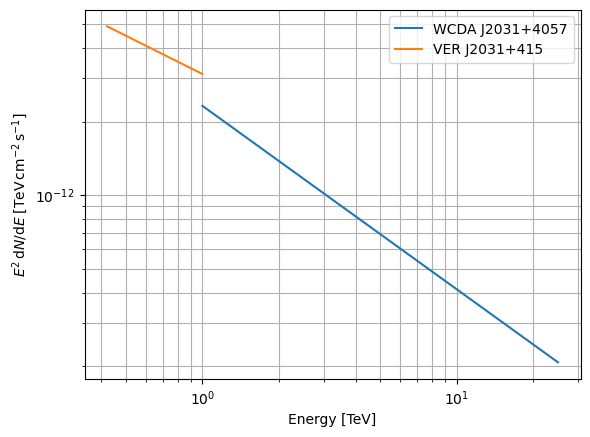

In [40]:
class LowEnergyCutoffPowerLaw(SpectralModel):
    """Power law with exponential cutoff at low energies."""

    tag = "LowEnergyCutoffPowerLaw"

    norm = Parameter("norm", 1.44e-8, unit="GeV-1 cm-2 s-1")
    gamma = Parameter("gamma", 2.52)
    reference = Parameter("reference", 2.27, unit="GeV", frozen=True)
    ecut = Parameter("ecut", 0.1, unit="TeV")

    @staticmethod
    def evaluate(energy, norm, gamma, reference, ecut):
        return (
            norm
            * (energy / reference) ** (-gamma)
            * np.exp(-ecut / energy)
        )




# LHAASO J2031+4127u (VER J2032+414 - TeV J2032+4130 - MGRO J2031+41) 
energy_bounds_WCDA = [1, 25] * u.TeV
model_WCDA = PowerLawSpectralModel(
    index=2.75,
    amplitude="0.11e-9 TeV-1 m-2 s-1",
    reference=7 * u.TeV,
)
energy_WCDA = np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde_WCDA = model_WCDA(energy_WCDA)
e2dnde_WCDA = (energy_WCDA**2 * dnde_WCDA).to("TeV cm-2 s-1")


energy_bounds = [422, 42200] * u.GeV
model_VER= PowerLawSpectralModel(index=2.52,amplitude="1.44e-8 GeV-1 cm-2 s-1", reference=2.27 * u.GeV,)
model_VER_low = LowEnergyCutoffPowerLaw()
# Energy grid 
energy_VER = np.logspace(np.log10(0.422), np.log10(1), 200) * u.TeV
# dN/dE and SED
dnde_VER = model_VER(energy_VER)
e2dnde_VER = (energy_VER**2 * dnde_VER).to("TeV cm-2 s-1")
#dnde_VER_low = model_VER_low(energy_VER)
#e2dnde_VER_low = (energy_VER**2 * dnde_VER_low).to("TeV cm-2 s-1")

plt.loglog(energy_WCDA, e2dnde_WCDA, label="WCDA J2031+4057")
#plt.loglog(energy_VER, e2dnde_VER_low, label="VER J2031+415_cutoff")
plt.loglog(energy_VER, e2dnde_VER, label="VER J2031+415")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{TeV\,cm^{-2}\,s^{-1}}]$")
plt.legend()
plt.grid(which="both")
plt.show()

Parametri fit:
 N0 = 3.184e-12, gamma = 3.03, Ecut = 0.421 TeV


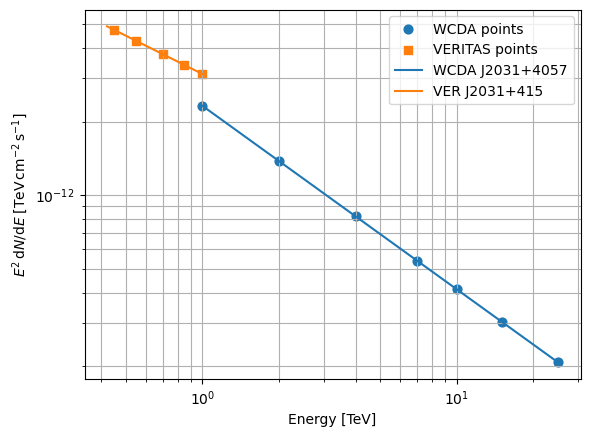

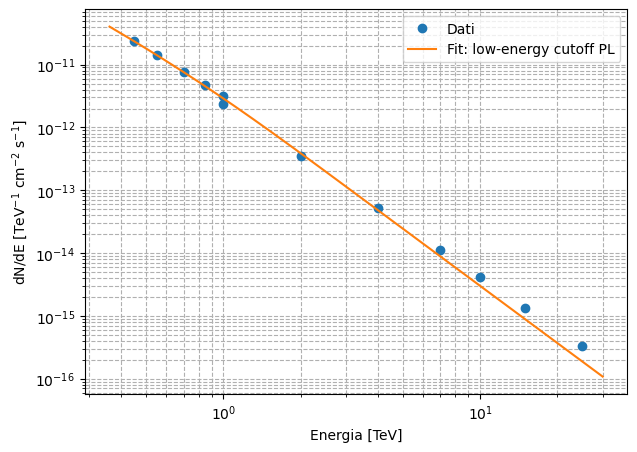

In [81]:
class LowEnergyCutoffPowerLaw(SpectralModel):
    """Power law with exponential cutoff at low energies."""

    tag = "LowEnergyCutoffPowerLaw"

    norm = Parameter("norm", 1.44e-8, unit="GeV-1 cm-2 s-1")
    gamma = Parameter("gamma", 2.52)
    reference = Parameter("reference", 2.27, unit="GeV", frozen=True)
    ecut = Parameter("ecut", 0.1, unit="TeV")

    @staticmethod
    def evaluate(energy, norm, gamma, reference, ecut):
        return (
            norm
            * (energy / reference) ** (-gamma)
            * np.exp(-ecut / energy)
        )




# LHAASO J2031+4127u (VER J2032+414 - TeV J2032+4130 - MGRO J2031+41) 
energy_bounds_WCDA = [1, 25] * u.TeV
model_WCDA = PowerLawSpectralModel(
    index=2.75,
    amplitude="0.11e-9 TeV-1 m-2 s-1",
    reference=7 * u.TeV,
)
energy_WCDA = np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde_WCDA = model_WCDA(energy_WCDA)
e2dnde_WCDA = (energy_WCDA**2 * dnde_WCDA).to("TeV cm-2 s-1")


energy_bounds = [422, 42200] * u.GeV
model_VER= PowerLawSpectralModel(index=2.52,amplitude="1.44e-8 GeV-1 cm-2 s-1", reference=2.27 * u.GeV,)
model_VER_low = LowEnergyCutoffPowerLaw()
# Energy grid 
energy_VER = np.logspace(np.log10(0.422), np.log10(1), 200) * u.TeV
# dN/dE and SED
dnde_VER = model_VER(energy_VER)
e2dnde_VER = (energy_VER**2 * dnde_VER).to("TeV cm-2 s-1")
#dnde_VER_low = model_VER_low(energy_VER)
#e2dnde_VER_low = (energy_VER**2 * dnde_VER_low).to("TeV cm-2 s-1")


energy_WCDA_pts = np.array([1, 2, 4, 7, 10, 15, 25]) * u.TeV
dnde_WCDA_pts = model_WCDA(energy_WCDA_pts)
e2dnde_WCDA_pts = (energy_WCDA_pts**2 * dnde_WCDA_pts).to("TeV cm-2 s-1")
energy_VER_pts = np.array([0.45, 0.55, 0.7, 0.85, 1.0]) * u.TeV
dnde_VER_pts = model_VER(energy_VER_pts)
e2dnde_VER_pts = (energy_VER_pts**2 * dnde_VER_pts).to("TeV cm-2 s-1")
# punti
plt.scatter(
    energy_WCDA_pts, e2dnde_WCDA_pts,
    marker="o", s=40, label="WCDA points"
)

plt.scatter(
    energy_VER_pts, e2dnde_VER_pts,
    marker="s", s=40, label="VERITAS points"
)

plt.loglog(energy_WCDA, e2dnde_WCDA, label="WCDA J2031+4057")
#plt.loglog(energy_VER, e2dnde_VER_low, label="VER J2031+415_cutoff")
plt.loglog(energy_VER, e2dnde_VER, label="VER J2031+415")
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{TeV\,cm^{-2}\,s^{-1}}]$")
plt.legend()
plt.grid(which="both")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- I tuoi dati combinati ---
energy_all = np.concatenate([energy_VER_pts.to("TeV").value, energy_WCDA_pts.to("TeV").value])
dnde_all = np.concatenate([dnde_VER_pts.to("TeV-1 cm-2 s-1").value, dnde_WCDA_pts.to("TeV-1 cm-2 s-1").value])

# Esempio di dati fittabili (sostituisci con i tuoi)
#energy_all = np.array([0.1, 0.2, 0.5, 1, 2, 5, 10])  # TeV
#dnde_all = np.array([1e-10, 8e-11, 5e-11, 3e-11, 1.5e-11, 5e-12, 1e-12])  # TeV^-1 cm^-2 s^-1

# --- Modello: low-energy cutoff power law ---
def low_energy_cutoff_plaw(E, N0, gamma, Ecut):
    """
    N0: normalizzazione
    gamma: indice spettrale
    Ecut: cutoff a bassa energia
    """
    return N0 * (E/1.0)**(-gamma) * (1 - np.exp(-E/Ecut))

# --- Fit dei dati ---
# valori iniziali dei parametri: [N0, gamma, Ecut]
p0 = [1e-11, 2.6, 0.04]

# curve_fit
popt, pcov = curve_fit(low_energy_cutoff_plaw, energy_all, dnde_all, p0=p0)

N0_fit, gamma_fit, Ecut_fit = popt
print(f"Parametri fit:\n N0 = {N0_fit:.3e}, gamma = {gamma_fit:.2f}, Ecut = {Ecut_fit:.3f} TeV")

# --- Plot ---
E_plot = np.logspace(np.log10(min(energy_all)*0.8), np.log10(max(energy_all)*1.2), 500)
plt.figure(figsize=(7,5))
plt.loglog(energy_all, dnde_all, 'o', label='Dati')
plt.loglog(E_plot, low_energy_cutoff_plaw(E_plot, *popt), '-', label='Fit: low-energy cutoff PL')
plt.xlabel("Energia [TeV]")
plt.ylabel(r"dN/dE [TeV$^{-1}$ cm$^{-2}$ s$^{-1}$]")
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()



In [49]:
ra = 307.89 * u.deg
dec = 40.96 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)


gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.33 deg")
print(gauss)

79.75005291943432 deg 0.8336845416680935 deg
GaussianSpatialModel

type  name   value    unit   error      min        max    frozen link prior
---- ----- ---------- ---- --------- ---------- --------- ------ ---- -----
     lon_0 7.9750e+01  deg 0.000e+00        nan       nan  False           
     lat_0 8.3368e-01  deg 0.000e+00 -9.000e+01 9.000e+01  False           
     sigma 3.3000e-01  deg 0.000e+00  0.000e+00       nan  False           
         e 0.0000e+00      0.000e+00  0.000e+00 1.000e+00   True           
       phi 0.0000e+00  deg 0.000e+00        nan       nan   True           


In [50]:
model = SkyModel(spatial_model= gauss, spectral_model=model_WCDA, name="LHAASO J2031+4057")
models = Models([model])

print(models.to_yaml())
models.write("LHAASOJ2031+4057.yaml", overwrite=True)


components:
-   name: LHAASO J2031+4057
    type: SkyModel
    spectral:
        type: PowerLawSpectralModel
        parameters:
        -   name: index
            value: 2.63
        -   name: amplitude
            value: 1.27e-09
            unit: TeV-1 s-1 m-2
        -   name: reference
            value: 7.0
            unit: TeV
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 79.75005291943432
            unit: deg
        -   name: lat_0
            value: 0.8336845416680935
            unit: deg
        -   name: sigma
            value: 0.33
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 1.3
    date: '2026-02-02T15:27:48.842877'
    origin: null



In [45]:
spatial_model = GaussianSpatialModel(lon_0="80.21 deg", lat_0=" 1.1 deg", sigma="0.15 deg")
model = SkyModel(spatial_model = spatial_model, spectral_model=model_VER, name="VER J2031+415")
models = Models([model])

print(models.to_yaml())
models.write("VERJ2031+415.yaml", overwrite=True)


components:
-   name: VER J2031+415
    type: SkyModel
    spectral:
        type: PowerLawSpectralModel
        parameters:
        -   name: index
            value: 2.52
        -   name: amplitude
            value: 1.44e-08
            unit: GeV-1 s-1 cm-2
        -   name: reference
            value: 2.27
            unit: GeV
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 80.21
            unit: deg
        -   name: lat_0
            value: 1.1
            unit: deg
        -   name: sigma
            value: 0.15
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 1.3
    date: '2026-02-02T15:24:18.833035'
    origin: null



### Cyg Bubble

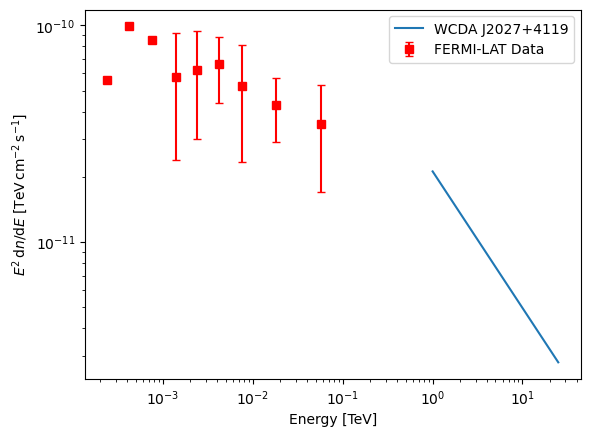

In [53]:
# LHAASO J2027+4119
energy_bounds_WCDA = [1, 25] * u.TeV
model_WCDA = PowerLawSpectralModel(
    index=2.63,
    amplitude="1.27e-9 TeV-1 m-2 s-1",
    reference=7 * u.TeV,
)
ra = 307.43 * u.deg
dec = 41.05 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg
spatial_WCDA = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="2.17 deg")

energy_WCDA = np.logspace(np.log10(1), np.log10(25), 200) * u.TeV


dnde_WCDA = model_WCDA(energy_WCDA)
e2dnde_WCDA = (energy_WCDA**2 * dnde_WCDA).to("TeV cm-2 s-1")

plt.loglog(energy_WCDA, e2dnde_WCDA, label="WCDA J2027+4119")


energy_fermilat = np.array([240, 420, 750, 1400, 2400, 4200, 7600, 18000, 57000]) * u.MeV
energy_fermilat = energy_fermilat.to(u.TeV)

e2dnde_fermilat = np.array([5.6e-5, 9.9e-5, 8.6e-5, 5.8e-5, 6.2e-5, 6.6e-5, 5.25e-5, 4.3e-5, 3.5e-5]) * u.MeV / (u.cm**2 * u.s)
e2dnde_fermilat = e2dnde_fermilat.to(u.TeV / (u.cm**2 * u.s))
err_fermilat = np.array([
    0, 0, 0, 3.4e-5, 3.2e-5,
    2.2e-5, 2.9e-5, 1.4e-5, 1.8e-5
]) * u.MeV / (u.cm**2 * u.s)


err_fermilat = err_fermilat.to(u.TeV / (u.cm**2 * u.s))




plt.grid(which="both")
plt.errorbar(energy_fermilat, e2dnde_fermilat, yerr=err_fermilat, fmt='s', color='red', ecolor='red', capsize=3, linestyle='none', label='FERMI-LAT Data')
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}n/\mathrm{d}E\;[\mathrm{TeV\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
plt.show()

FERMI-only log-parabola:
A     = 8.186e-12 TeV-1 cm-2 s-1
alpha = 2.614
beta  = 0.046


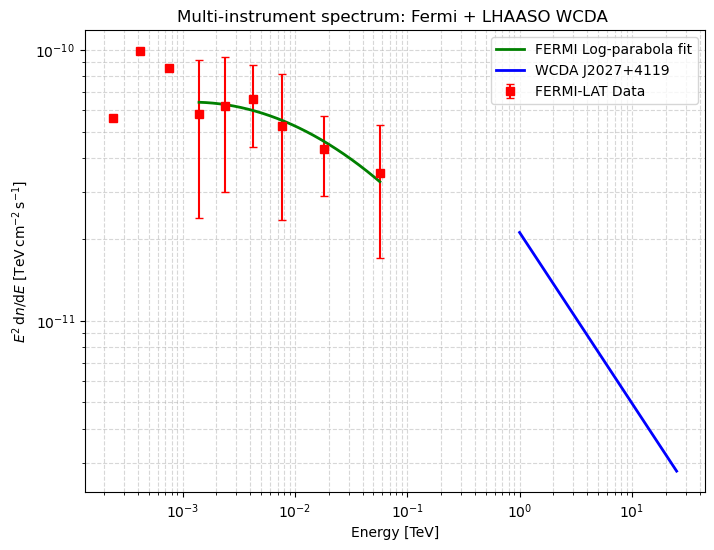

In [7]:
#log-parabola function
def logparabola_dnde(E, A, alpha, beta):
    E0 = 1.0  # TeV
    return A * (E / E0) ** (-(alpha + beta * np.log(E / E0)))

#Fermi data
energy_fermilat = np.array([240, 420, 750, 1400, 2400, 4200, 7600, 18000, 57000]) * u.MeV
energy_fermilat = energy_fermilat.to(u.TeV)

e2dnde_fermilat = np.array([5.6e-5, 9.9e-5, 8.6e-5, 5.8e-5, 6.2e-5, 6.6e-5, 5.25e-5, 4.3e-5, 3.5e-5]) * u.MeV / (u.cm**2 * u.s)
e2dnde_fermilat = e2dnde_fermilat.to(u.TeV / (u.cm**2 * u.s))

err_fermilat = np.array([0, 0, 0, 3.4e-5, 3.2e-5, 2.2e-5, 2.9e-5, 1.4e-5, 1.8e-5]) * u.MeV / (u.cm**2 * u.s)
err_fermilat = err_fermilat.to(u.TeV / (u.cm**2 * u.s))

# Convert to dN/dE
dnde_fermi = (e2dnde_fermilat / energy_fermilat**2).to(u.TeV**-1 / (u.cm**2 * u.s))
err_dnde_fermi = (err_fermilat / energy_fermilat**2).to(u.TeV**-1 / (u.cm**2 * u.s))

E = energy_fermilat.to_value(u.TeV)
Y = dnde_fermi.value
Yerr = err_dnde_fermi.value

# Remove points with zero error
mask = Yerr > 0
E = E[mask]
Y = Y[mask]
Yerr = Yerr[mask]

#fit
logY = np.log10(Y)
logYerr = Yerr / Y / np.log(10)

def log_fit(E, logA, alpha, beta):
    return np.log10(logparabola_dnde(E, 10**logA, alpha, beta))

p0 = [-11.5, 2.2, 0.1]
bounds = ([-20, 0.5, 0.0], [-5, 4.0, 2.0])

popt, pcov = curve_fit(log_fit, E, logY, sigma=logYerr, p0=p0, bounds=bounds, absolute_sigma=True, maxfev=20000)
logA, alpha, beta = popt
A = 10**logA

print("FERMI-only log-parabola:")
print(f"A     = {A:.3e} TeV-1 cm-2 s-1")
print(f"alpha = {alpha:.3f}")
print(f"beta  = {beta:.3f}")


model_fermi = LogParabolaSpectralModel(
    amplitude=A * u.Unit("TeV-1 cm-2 s-1"),
    alpha=alpha,
    beta=beta,
    reference=1.0 * u.TeV
)

#fit curve
E_plot = np.logspace(np.log10(min(E)), np.log10(max(E)), 500)
Y_fit = logparabola_dnde(E_plot, A, alpha, beta)
e2Y_fit = E_plot**2 * Y_fit  # E^2 dN/dE

#WCDA Model
energy_WCDA = np.logspace(np.log10(1), np.log10(25), 200) * u.TeV
model_WCDA = PowerLawSpectralModel(index=2.63, amplitude="1.27e-9 TeV-1 m-2 s-1", reference=7 * u.TeV)
dnde_WCDA = model_WCDA(energy_WCDA)
e2dnde_WCDA = (energy_WCDA**2 * dnde_WCDA).to("TeV cm-2 s-1")


plt.figure(figsize=(8,6))

# Dati Fermi con errori
plt.errorbar(energy_fermilat, e2dnde_fermilat, yerr=err_fermilat, fmt='s', color='red', ecolor='red', capsize=3, linestyle='none', label='FERMI-LAT Data')

# Log-parabola fit Fermi
plt.loglog(E_plot, e2Y_fit, color='green', lw=2, label='FERMI Log-parabola fit')

# WCDA & KM2A
plt.loglog(energy_WCDA, e2dnde_WCDA, color='blue', lw=2, label='WCDA J2027+4119')
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}n/\mathrm{d}E\;[\mathrm{TeV\,cm^{-2}\,s^{-1}}]$")
plt.title("Multi-instrument spectrum: Fermi + LHAASO WCDA ")
plt.legend()
plt.grid(which="both", ls="--", alpha=0.5)
plt.show()


In [54]:
model = SkyModel(spatial_model = spatial_WCDA, spectral_model=model_WCDA, name="LHAASO J2027+4119")
models = Models([model])

print(models.to_yaml())
models.write("LHAASOJ2027+4119.yaml", overwrite=True)


components:
-   name: LHAASO J2027+4119
    type: SkyModel
    spectral:
        type: PowerLawSpectralModel
        parameters:
        -   name: index
            value: 2.63
        -   name: amplitude
            value: 1.27e-09
            unit: TeV-1 s-1 m-2
        -   name: reference
            value: 7.0
            unit: TeV
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 79.6182412547296
            unit: deg
        -   name: lat_0
            value: 1.1672065037476738
            unit: deg
        -   name: sigma
            value: 2.17
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metadata:
    creator: Gammapy 1.3
    date: '2026-02-02T15:31:53.024607'
    origin: null



In [9]:
model = SkyModel(spectral_model=model_fermi, name="fermi cocoon")
models = Models([model])

print(models.to_yaml())
models.write("fermi_cocoon.yaml", overwrite=True)

components:
-   name: fermi cocoon
    type: SkyModel
    spectral:
        type: LogParabolaSpectralModel
        parameters:
        -   name: amplitude
            value: 8.185954128868864e-12
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 1.0
            unit: TeV
        -   name: alpha
            value: 2.6138240904537655
        -   name: beta
            value: 0.0457467785247994
metadata:
    creator: Gammapy 1.3
    date: '2026-02-02T08:17:51.228262'
    origin: null



### Cyg X3

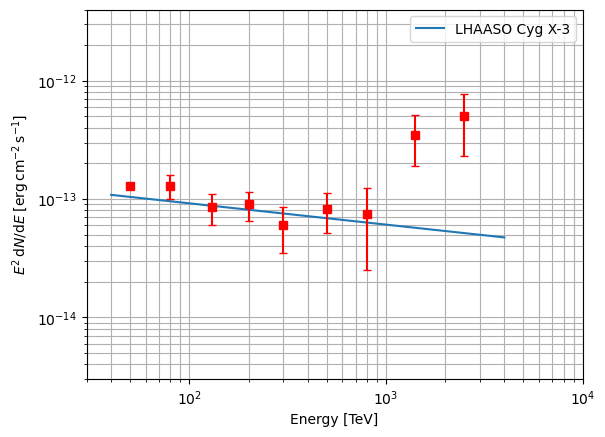

In [82]:
e2dnde_value = [1.3e-13, 1.3e-13, 8.5e-14, 9e-14, 6e-14, 8.2e-14, 7.5e-14, 3.5e-13, 5e-13]
energy_value = [50, 80, 130, 200, 300, 500, 800, 1400, 2500]
err_value = np.array([
    0,
    0.3e-13,
    0.25e-13,
    0.25e-13,
    0.25e-13,
    0.3e-13,
    0.5e-13,
    1.6e-13,
    2.7e-13
])
# Power-law model (LHAASO Cyg X-3)
model = PowerLawSpectralModel(
    index=2.18,
    amplitude=2.6e-17 * u.Unit("TeV-1 cm-2 s-1"),
    reference=50 * u.TeV,
)

# Energy grid (40–4000 TeV)
energy = np.logspace(np.log10(40), np.log10(4000), 200) * u.TeV

# dN/dE and SED
dnde = model(energy)
e2dnde = (energy**2 * dnde).to("erg cm-2 s-1")


# Plot
plt.loglog(energy, e2dnde, label="LHAASO Cyg X-3")
plt.errorbar(
    energy_value,
    e2dnde_value,
    yerr=err_value,
    fmt='s',          # marker quadrato (come nel plot)
    color='red',
    ecolor='red',     # colore delle barre di errore
    capsize=3,        # cappucci
    linestyle='none'  # niente linee di collegamento
)

plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
plt.ylim(3e-15, 4e-12)
plt.xlim(30, 10**4)


plt.show()


In [83]:
model = SkyModel(spectral_model=model, name="LHAASO Cygnus X3 PL")
models = Models([model])

print(models.to_yaml())
models.write("LHAASO_CygX3_PL.yaml", overwrite=True)

components:
-   name: LHAASO Cygnus X3 PL
    type: SkyModel
    spectral:
        type: PowerLawSpectralModel
        parameters:
        -   name: index
            value: 2.18
        -   name: amplitude
            value: 2.6e-17
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 50.0
            unit: TeV
metadata:
    creator: Gammapy 1.3
    date: '2026-02-03T10:04:31.296346'
    origin: null



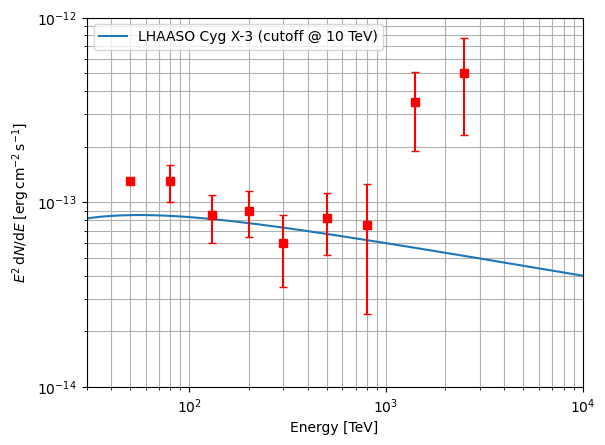

In [86]:
#creo un modello spettrale personalizzato che eredita da spectral model
class LowEnergyCutoffPowerLaw(SpectralModel):
    """Power law with exponential cutoff at low energies."""

    tag = "CutoffPowerLaw"

    norm = Parameter("norm", 2.6e-17, unit="TeV-1 cm-2 s-1")
    gamma = Parameter("gamma", 2.18)
    reference = Parameter("reference", 50, unit="TeV", frozen=True)
    ecut = Parameter("ecut", 10, unit="TeV")

    @staticmethod
    def evaluate(energy, norm, gamma, reference, ecut):
        return (
            norm
            * (energy / reference) ** (-gamma)
            * np.exp(-ecut / energy)
        )


# Instantiate model
model = LowEnergyCutoffPowerLaw()

# Energy grid (40–4000 TeV)
energy = np.logspace(np.log10(30), np.log10(10**4), 200) * u.TeV

# dN/dE and E^2 dN/dE
dnde = model(energy)
e2dnde = (energy**2 * dnde).to("erg cm-2 s-1")

# Plot
plt.loglog(
    energy,
    e2dnde,
    label="LHAASO Cyg X-3 (cutoff @ 10 TeV)"
)
plt.errorbar(
    energy_value,
    e2dnde_value,
    yerr=err_value,
    fmt='s',          # marker quadrato (come nel plot)
    color='red',
    ecolor='red',     # colore delle barre di errore
    capsize=3,        # cappucci
    linestyle='none'  # niente linee di collegamento
)
plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
plt.ylim(1e-14, 1e-12)
plt.xlim(30, 10**4)
plt.legend()
plt.show()

In [13]:
model = SkyModel(spectral_model=model, name="LHAASO Cygnus X3 CutOffPL")
models = Models([model])

print(models.to_yaml())
models.write("LHAASO_CygX3_CutOffPL.yaml", overwrite=True)

components:
-   name: LHAASO Cygnus X3 CutOffPL
    type: SkyModel
    spectral:
        type: LowEnergyCutoffPowerLaw
        parameters:
        -   name: norm
            value: 2.6e-17
            unit: TeV-1 s-1 cm-2
        -   name: gamma
            value: 2.18
        -   name: reference
            value: 50.0
            unit: TeV
        -   name: ecut
            value: 10.0
            unit: TeV
metadata:
    creator: Gammapy 1.3
    date: '2026-02-02T08:19:50.596861'
    origin: null



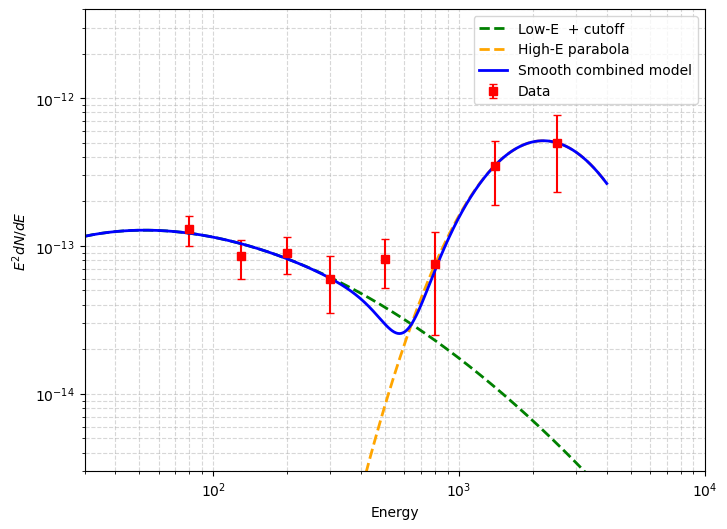

LOW ENERGY MODEL
a        = 0.429
logEp    = 1.500
Ep       = 31.6
Ec (cut) = 10.0


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ======================
# DATI
# ======================
energy_value = np.array([80, 130, 200, 300, 500, 800, 1400, 2500])
e2dnde_value = np.array([
    1.3e-13, 8.5e-14, 9.0e-14, 6.0e-14,
    8.2e-14, 7.5e-14, 3.5e-13, 5.0e-13
])
err_value = np.array([
    0.3e-13, 0.25e-13, 0.25e-13, 0.25e-13,
    0.3e-13, 0.5e-13, 1.6e-13, 2.7e-13
])

# ======================
# MODELLI
# ======================

# HIGH energy: parabola normale
def logparabola_high(logE, a, b, c):
    return a * logE**2 + b * logE + c

# LOW energy: parabola concava + cutoff a basse E
def logparabola_low_cut(logE, a, logEp, c, Ec):
    E = 10**logE
    return (
        -a * (logE - logEp)**2
        + c
        - Ec / (E * np.log(10))
    )

# ======================
# DATI IN LOG
# ======================
logE = np.log10(energy_value)
logY = np.log10(e2dnde_value)

logErr = err_value / (e2dnde_value * np.log(10))

# ======================
# FIT LOW ENERGY (CUT-OFF + CONCAVITÀ OPPOSTA)
# ======================
p0_low = [1.0, np.log10(200), -13, 200]
bounds_low = (
    [0.01, 1.5, -16, 10],
    [10.0, 3.5, -10, 2000]
)

popt_low, _ = curve_fit(
    logparabola_low_cut,
    logE[:4],
    logY[:4],
    sigma=logErr[:4],
    p0=p0_low,
    bounds=bounds_low,
    absolute_sigma=True,
    maxfev=20000
)

# ======================
# FIT HIGH ENERGY
# ======================
popt_high, _ = curve_fit(
    logparabola_high,
    logE[5:],
    logY[5:],
    sigma=logErr[5:],
    absolute_sigma=True
)

# ======================
# MODELLO COMBINATO LISCIO
# ======================
def smooth_combined(E, Etrans=600, width=0.05):
    logE = np.log10(E)

    f_low = 10**logparabola_low_cut(logE, *popt_low)
    f_high = 10**logparabola_high(logE, *popt_high)

    x = (logE - np.log10(Etrans)) / width
    S = 1.0 / (1.0 + np.exp(-x))

    return f_low**(1 - S) * f_high**S

# ======================
# PLOT
# ======================
energy_fit = np.logspace(np.log10(30), np.log10(4000), 600)

plt.figure(figsize=(8, 6))

plt.errorbar(
    energy_value, e2dnde_value, yerr=err_value,
    fmt='s', color='red', capsize=3, label='Data'
)

plt.loglog(
    energy_fit,
    10**logparabola_low_cut(np.log10(energy_fit), *popt_low),
    '--', lw=2, color='green', label='Low-E  + cutoff'
)

plt.loglog(
    energy_fit,
    10**logparabola_high(np.log10(energy_fit), *popt_high),
    '--', lw=2, color='orange', label='High-E parabola'
)

plt.loglog(
    energy_fit,
    smooth_combined(energy_fit),
    '-', lw=2, color='blue', label='Smooth combined model'
)

plt.xlabel("Energy")
plt.ylabel(r"$E^2 dN/dE$")
plt.grid(which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.xlim(30, 1e4)
plt.ylim(3e-15, 4e-12)
plt.show()

# ======================
# PARAMETRI
# ======================
a, logEp, c, Ec = popt_low
print("LOW ENERGY MODEL")
print(f"a        = {a:.3f}")
print(f"logEp    = {logEp:.3f}")
print(f"Ep       = {10**logEp:.1f}")
print(f"Ec (cut) = {Ec:.1f}")


In [33]:
emodel = SkyModel(spectral_model=model, name="LHAASO Cygnus X3 smooth_combined")
models = Models([model])

print(models.to_yaml())
models.write("LHAASO_CygX3_smooth_combined.yaml", overwrite=True)


components:
-   name: LHAASO Cygnus X3 smooth_combined
    type: SkyModel
    spectral:
        type: SmoothCombinedE2SpectralModel
        parameters:
        -   name: a_low
            value: 0.4285446407247179
        -   name: logEp
            value: 1.50000000000031
        -   name: c_low
            value: -12.789667740108529
        -   name: Ec
            value: 10.000000000000002
            unit: GeV
        -   name: a_high
            value: -4.319559290224415
        -   name: b_high
            value: 28.882639221071216
        -   name: c_high
            value: -60.568889767474
        -   name: Etrans
            value: 600.0
            unit: GeV
        -   name: width
            value: 0.05
metadata:
    creator: Gammapy 1.3
    date: '2026-02-02T08:45:54.278374'
    origin: null

